# Pretrained YOLOv8 Fine-Tuning on COCO Dataset

To complete our YOLO exercises, this notebook fine-tunes a **pretrained YOLOv8n** model on the COCO dataset for multiple classes. After training a Mini-YOLO from scratch in the last exercises, this is the more practical approach that you would follow for realizing your own applications. 

**Steps in this exercise:**
- Load COCO images and labels 
- Convert COCO annotations to YOLO format for our three classes
- Build a minimal YOLO dataset structure (`images/train|val`, `labels/train|val`)
- Fine-tune the pretrained `yolov8n.pt` and evaluate

In [1]:
# Imports
from pathlib import Path
import shutil
import random

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
random.seed(42)
np.random.seed(42)

## 1) Load COCO128 data

The dataset folder has already been prepared for you under `/data/coco128_split/`. It contains a training and validation subset:

- `images/train`, `labels/train`
- `images/val`, `labels/val`

In [2]:
from ultralytics.utils import SETTINGS

coco128_root = Path("/data/coco128_split")
print("COCO128 root:", coco128_root.resolve())

# already prepared split f
train_src_imgs = coco128_root / "images" / "train"
train_src_lbls = coco128_root / "labels" / "train"
val_src_imgs   = coco128_root / "images" / "val"
val_src_lbls   = coco128_root / "labels" / "val"

# quick checks
for split, img_dir, lbl_dir in [
    ("train", train_src_imgs, train_src_lbls),
    ("val",   val_src_imgs,   val_src_lbls),
]:
    n_img = len(list(img_dir.glob("*.jpg"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
    print(f"{split}: images={n_img}, labels={n_lbl}")
    assert n_img > 0 and n_lbl > 0, f"Missing or empty {split} split at {img_dir} / {lbl_dir}"

print("Using existing dataset at:", coco128_root.resolve())

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/student/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
COCO128 root: /data/coco128_split
train: images=128, labels=126
val: images=25, labels=25
Using existing dataset at: /data/coco128_split


## 2) Create dataset YAML file for Ultralytics

Now we create the dataset YAML file required by Ultralytics YOLO implementations. We specify the paths to the train and val image directories as well as the class names.

In [3]:
# Write a dataset YAML for the prepared split
from pathlib import Path

yaml_path = Path("coco128_split.yaml")

names = [
 "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat","traffic light",
 "fire hydrant","stop sign","parking meter","bench","bird","cat","dog","horse","sheep","cow",
 "elephant","bear","zebra","giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee",
 "skis","snowboard","sports ball","kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket","bottle",
 "wine glass","cup","fork","knife","spoon","bowl","banana","apple","sandwich","orange",
 "broccoli","carrot","hot dog","pizza","donut","cake","chair","couch","potted plant","bed",
 "dining table","toilet","tv","laptop","mouse","remote","keyboard","cell phone","microwave","oven",
 "toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear","hair drier","toothbrush"
]

nc = len(names)

yaml_text = f"""path: {coco128_root.resolve()}
train: images/train
val: images/val

nc: {nc}
names: {names}
"""

yaml_path.write_text(yaml_text, encoding="utf-8")
print("Wrote dataset YAML to:", yaml_path.resolve())
print("\nPreview:\n", yaml_text)


Wrote dataset YAML to: /workspace/cd1821-vision-CNNs/lesson-9-detection/demos/coco128_split.yaml

Preview:
 path: /data/coco128_split
train: images/train
val: images/val

nc: 80
names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scisso

## 3) Fine-tune pretrained YOLOv8n on COCO

Now it's time to fine-tune a pretrained YOLOv8 model on our COCO dataset. We'll use the ultralytics package for this.

Tips:
- If VRAM is limited, reduce `batch` or set `imgsz=512`.
- If you want a very stable quick run, set `freeze=10` (freeze backbone layers) and use a smaller learning rate.


In [ ]:
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print("Training device:", device)

# Pretrained detection model (COCO)
model = YOLO("yolov8n.pt")

# Determinism (optional)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

results = model.train(
    data=yaml_path.as_posix(),
    epochs=10,
    imgsz=640,
    batch=16,
    device=device,
    workers=0,
    lr0=1e-4,          # lower LR for small demo dataset
    # freeze=10,       # optionally freeze backbone for stability
    verbose=True,
    name="yolov8n_coco128_multiclass"
)
results

Training device: 0
New https://pypi.org/project/ultralytics/8.4.12 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128_split.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_coco128_multiclass7, 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 21.3±16.8 MB/s, size: 46.0 KB)
train: Scanning /data/coco128_split/labels/train... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 1.4Kit/s 0.1s
WARNING ⚠️ train: Cache directory /data/coco128_split/labels is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 59.8±25.5 MB/s, size: 60.1 KB)
val: Scanning /data/coco128_split/labels/val... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 1.3Kit/s 0.0s
WARNING ⚠️ val: Cache directory /data/coco128_split/labels is not writeable, cache not saved.
Plotting labels to /workspace/cd1821-vision-CNNs/lesson-9-detection/demos/runs/detect/yolov8n_coco128_multiclass7/labels.jpg... 
optimizer: 'optimizer=auto' f

## 4) Evaluate and run predictions

Finally, we evaluate the model: We run predictions on validation images and calculate final evaluation metrics.


In [ ]:
# Evaluate
metrics = model.val(data=yaml_path.as_posix(), imgsz=640, batch=16, device=device)
print(metrics)

# Predict on the val split (saves images with boxes)
val_images_dir = coco128_root / "images" / "val"
pred_dir = Path("runs/predict_coco128_multiclass")
pred_dir.mkdir(parents=True, exist_ok=True)

_ = model.predict(
    source=val_images_dir.as_posix(),
    save=True,
    project=pred_dir.as_posix(),
    name="pred",
    imgsz=640,
    conf=0.25
)

print("Predictions saved under:", pred_dir.resolve())


Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1349.3±448.3 MB/s, size: 51.5 KB)
val: Scanning /data/coco128_split/labels/val... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 1.3Kit/s 0.0s
WARNING ⚠️ val: Cache directory /data/coco128_split/labels is not writeable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0it/s 2.1s4.1s
                   all         25        183       0.65      0.671      0.734      0.561
                person         14         50      0.769       0.84       0.85      0.645
                   car          2          2      0.655          1      0.995      0.696
            motorcycle          1          1      0.419          1      0.995      0.597
              airplane          1          1      0

Saved prediction images: 25


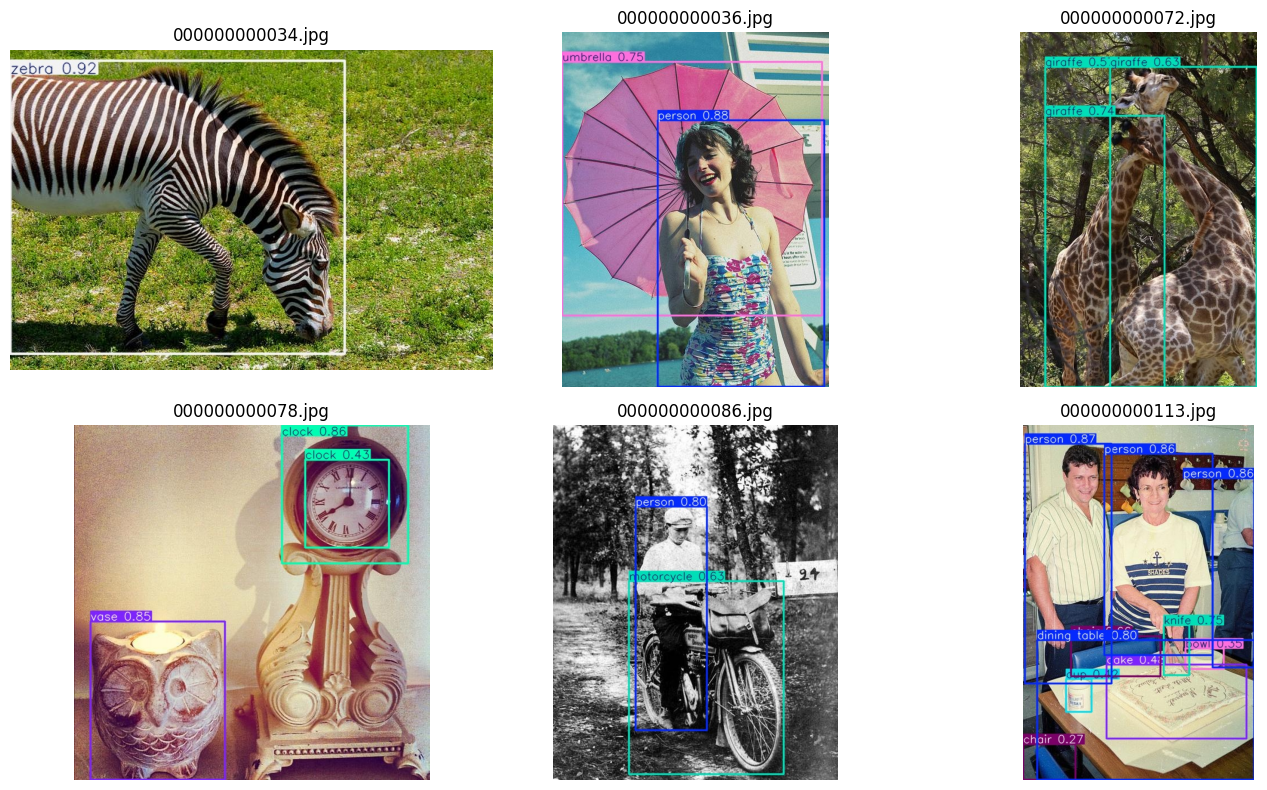

In [ ]:
# Visualize a few saved predictions
from PIL import Image

saved = sorted((pred_dir / "pred").glob("*.jpg"))
print("Saved prediction images:", len(saved))

n_show = min(6, len(saved))
if n_show == 0:
    print("No saved predictions found. Check the predict cell above.")
else:
    plt.figure(figsize=(14, 8))
    for i in range(n_show):
        img = Image.open(saved[i])
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(saved[i].name)
    plt.tight_layout()
    plt.show()


In [ ]:
# Evaluate the model to get final metrics
metrics = model.val(data=yaml_path.as_posix(), imgsz=640, batch=8, device=device)
print(metrics.results_dict)

Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1727.6±781.6 MB/s, size: 73.6 KB)
val: Scanning /data/coco128_split/labels/val... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 294.3it/s 0.1s
WARNING ⚠️ val: Cache directory /data/coco128_split/labels is not writeable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.2it/s 1.8s0.7s
                   all         25        183      0.647      0.685      0.742      0.559
                person         14         50      0.759       0.84      0.854      0.653
                   car          2          2      0.677          1      0.995      0.647
            motorcycle          1          1        0.4          1      0.995      0.597
              airplane          1          1      0.405          1      0.995      0.597
                   bus          1        

Now it's your turn! Why don't you get creative and build your own application with a pretrained YOLO detector based on this notebook? Maybe a simple grocery stock checker, a pet monitor or a lost-and-found detector? 🤩